### Problem Statement: Develop an AI model to analyze social media sentiment trends for financial markets.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/home/admin1/Twitter_Data.csv")
df

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0
...,...,...
162975,why these 456 crores paid neerav modi not reco...,-1.0
162976,dear rss terrorist payal gawar what about modi...,-1.0
162977,did you cover her interaction forum where she ...,0.0
162978,there big project came into india modi dream p...,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [7]:
df.isnull().sum()

clean_text    4
category      7
dtype: int64

In [9]:
df.dropna(inplace=True)

In [11]:
df.isnull().sum()

clean_text    0
category      0
dtype: int64

In [13]:
df['category'].value_counts()

category
 1.0    72249
 0.0    55211
-1.0    35509
Name: count, dtype: int64

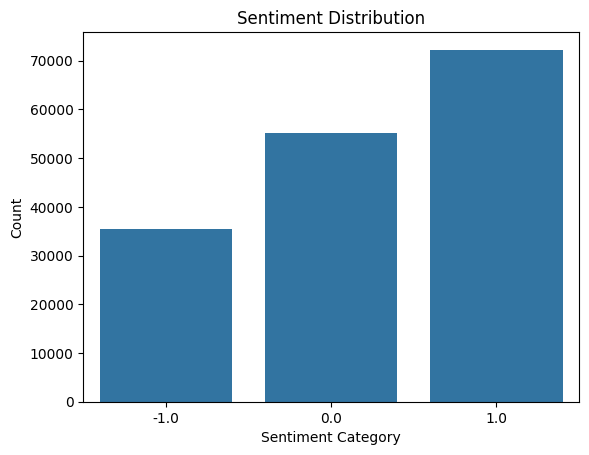

In [15]:
sns.countplot(x=df['category'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Category")
plt.ylabel("Count")

plt.show()

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(df['clean_text'])
y = df['category']

In [19]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2)

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [23]:
from sklearn.naive_bayes import MultinomialNB

NB = MultinomialNB()
NB.fit(x_train, y_train)

y_pred_NB = NB.predict(x_test)
print("NAIVE BAYES RESULTS ->\n")

print("Accuracy : ", accuracy_score(y_test, y_pred_NB))
print("Precision : ", precision_score(y_test, y_pred_NB, average='weighted'))
print("Recall : ", recall_score(y_test, y_pred_NB, average='weighted'))
print("F1 Score : ", f1_score(y_test, y_pred_NB, average='weighted'))

NAIVE BAYES RESULTS ->

Accuracy :  0.573633184021599
Precision :  0.7443538541973448
Recall :  0.573633184021599
F1 Score :  0.5048630800338637


In [25]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier()
RF.fit(x_train, y_train)

y_pred_RF = RF.predict(x_test)
print("RANDOM FOREST RESULTS ->\n")

print("Accuracy : ", accuracy_score(y_test, y_pred_RF))
print("Precision : ", precision_score(y_test, y_pred_RF, average='weighted'))
print("Recall : ", recall_score(y_test, y_pred_RF, average='weighted'))
print("F1 Score : ", f1_score(y_test, y_pred_RF, average='weighted'))

RANDOM FOREST RESULTS ->

Accuracy :  0.811560409891391
Precision :  0.829620509741775
Recall :  0.811560409891391
F1 Score :  0.7997546740958225


In [27]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(max_iter=500)
LR.fit(x_train, y_train)

y_pred_LR = LR.predict(x_test)
print("LOGISTIC REGRESSION RESULTS ->\n")

print("Accuracy : ", accuracy_score(y_test, y_pred_LR))
print("Precision : ", precision_score(y_test, y_pred_LR, average='weighted'))
print("Recall : ", recall_score(y_test, y_pred_LR, average='weighted'))
print("F1 Score : ", f1_score(y_test, y_pred_LR, average='weighted'))

LOGISTIC REGRESSION RESULTS ->

Accuracy :  0.9207829661900964
Precision :  0.9210584459082594
Recall :  0.9207829661900964
F1 Score :  0.9197082008815768


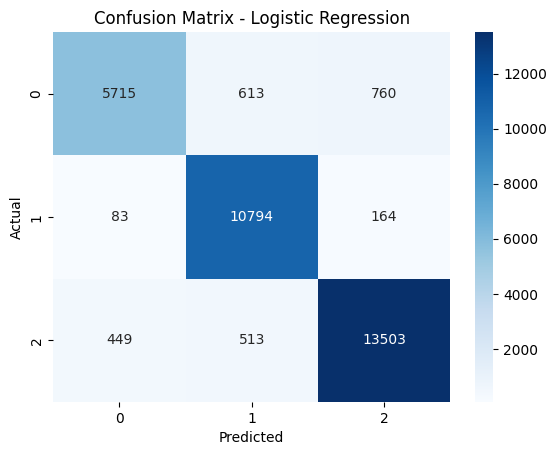

In [29]:
from sklearn.metrics import confusion_matrix

CM = confusion_matrix(y_test, y_pred_LR)
sns.heatmap(CM, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### REDDIT SENTIMENT

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
df = pd.read_csv("/home/admin1/Reddit_Data.csv")
df

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [62]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [64]:
df.dropna(inplace=True)

In [66]:
df.isnull().sum()

clean_comment    0
category         0
dtype: int64

In [68]:
df['category'].value_counts()

category
 1    15830
 0    13042
-1     8277
Name: count, dtype: int64

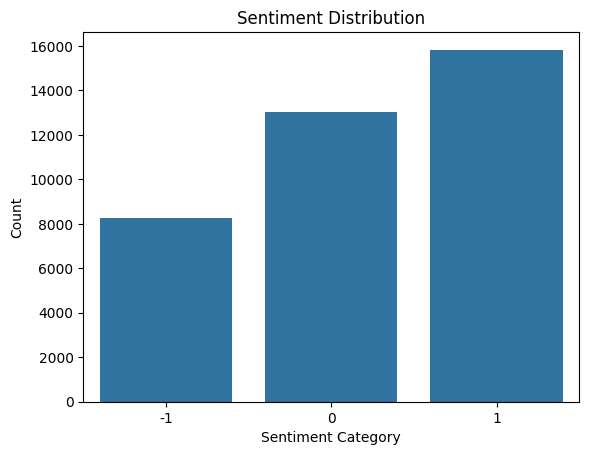

In [70]:
sns.countplot(x=df['category'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Category")
plt.ylabel("Count")

plt.show()

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(df['clean_comment'])
y = df['category']

In [76]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2)

In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [80]:
from sklearn.naive_bayes import MultinomialNB

NB = MultinomialNB()
NB.fit(x_train, y_train)

y_pred_NB = NB.predict(x_test)
print("NAIVE BAYES RESULTS ->\n")

print("Accuracy : ", accuracy_score(y_test, y_pred_NB))
print("Precision : ", precision_score(y_test, y_pred_NB, average='weighted'))
print("Recall : ", recall_score(y_test, y_pred_NB, average='weighted'))
print("F1 Score : ", f1_score(y_test, y_pred_NB, average='weighted'))

NAIVE BAYES RESULTS ->

Accuracy :  0.5359353970390309
Precision :  0.737197173641344
Recall :  0.5359353970390309
F1 Score :  0.46098725062261414


In [82]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier()
RF.fit(x_train, y_train)

y_pred_RF = RF.predict(x_test)
print("RANDOM FOREST RESULTS ->\n")

print("Accuracy : ", accuracy_score(y_test, y_pred_RF))
print("Precision : ", precision_score(y_test, y_pred_RF, average='weighted'))
print("Recall : ", recall_score(y_test, y_pred_RF, average='weighted'))
print("F1 Score : ", f1_score(y_test, y_pred_RF, average='weighted'))

RANDOM FOREST RESULTS ->

Accuracy :  0.7662180349932706
Precision :  0.7996801600982673
Recall :  0.7662180349932706
F1 Score :  0.7360107616200765


In [84]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(max_iter=500)
LR.fit(x_train, y_train)

y_pred_LR = LR.predict(x_test)
print("LOGISTIC REGRESSION RESULTS ->\n")

print("Accuracy : ", accuracy_score(y_test, y_pred_LR))
print("Precision : ", precision_score(y_test, y_pred_LR, average='weighted'))
print("Recall : ", recall_score(y_test, y_pred_LR, average='weighted'))
print("F1 Score : ", f1_score(y_test, y_pred_LR, average='weighted'))

LOGISTIC REGRESSION RESULTS ->

Accuracy :  0.8519515477792732
Precision :  0.8561702820559478
Recall :  0.8519515477792732
F1 Score :  0.8479751495037574


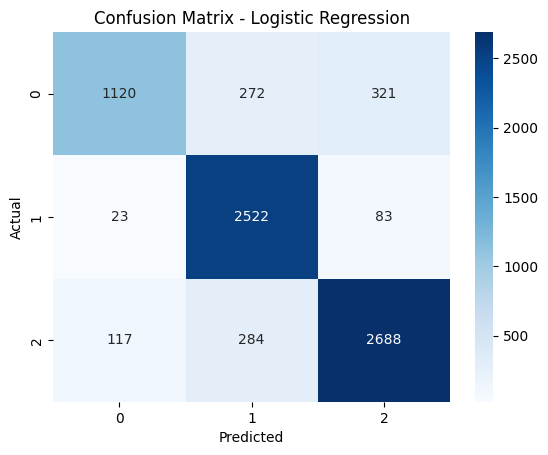

In [86]:
from sklearn.metrics import confusion_matrix

CM = confusion_matrix(y_test, y_pred_LR)
sns.heatmap(CM, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

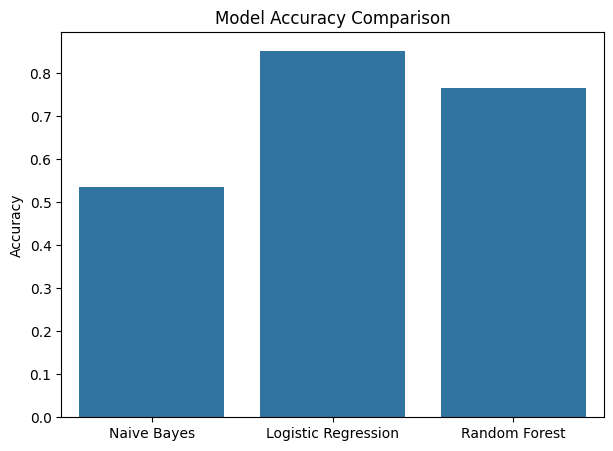

In [88]:
models = ['Naive Bayes','Logistic Regression','Random Forest']

accuracies = [accuracy_score(y_test, y_pred_NB), accuracy_score(y_test, y_pred_LR), accuracy_score(y_test, y_pred_RF)]

plt.figure(figsize=(7,5))
sns.barplot(x=models, y=accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()